In [ ]:
from src.paths import ROOT
from src.utils import *
from src.rsa.simj_rsa import SimjRSA, SimjRSAPlotsManager
import numpy as np
from scipy.stats import spearmanr
from src.indexing_and_formatting.image_indexing_utils import judj_subset

## Computing Noise Ceilings

In [4]:
def compute_noise_ceilings():
    part_rdms = open_pickle(ROOT / 'results/judj_rsa/simj.pkl')
    rdms = np.stack([part_rdms[str(part)] for part in range(1,9)])

    mean_rdm = rdms.mean(axis=0)
    ub_arr, lb_arr = np.empty(8), np.empty(8)
    for i in range(8):
        ub_arr[i], _ = spearmanr(rdms[i], mean_rdm)
        mean_wo_part = rdms[[el for el in np.arange(8) if el != i]].mean(axis=0)
        lb_arr[i], _ = spearmanr(rdms[i], mean_wo_part)

    return ub_arr.mean().item(), lb_arr.mean().item()

ub, lb = compute_noise_ceilings()


In [25]:
print(ub, lb)

0.5511608295607526 0.3619835896466451


## Plotting RSA Results

In [2]:
noise_ceilings = {'ub': 0.5511608295607526, 'lb': 0.3619835896466451}

In [3]:
pm = SimjRSAPlotsManager(noise_ceilings=noise_ceilings)

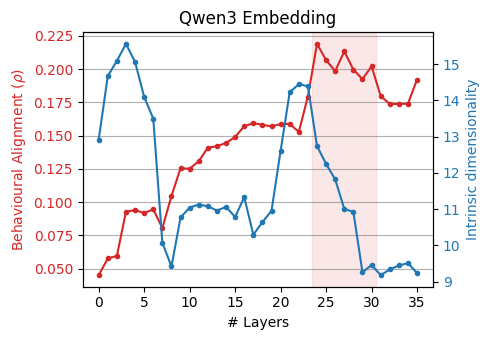

In [4]:
embedder= 'qwen3'
pm.linechart_intrinsic_dimensionality(embedder, axspan=(23.5, 30.5), save=True, file_name=f"simj_rs_id_{embedder}")

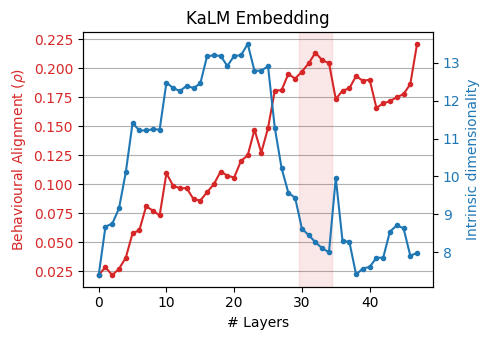

In [5]:
embedder= 'kalm'
pm.linechart_intrinsic_dimensionality(embedder, axspan=(29.5, 34.5), save=True, file_name=f"simj_rs_id_{embedder}")

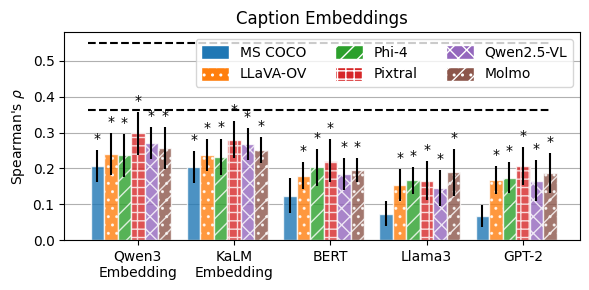

In [4]:
pm.barplot_all_lms(save=True, file_name='simj_rsa')

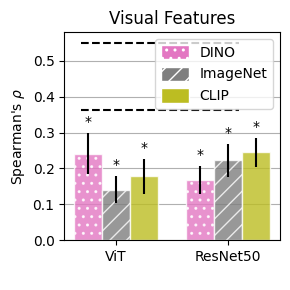

In [5]:
pm.barplot_all_vf(save=True, file_name='simj_rsa_vf')